# Modelltraining für Fraud Detection

## 1. Setup und Daten laden

In [ ]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

import keras_tuner as kt

try:
    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
except ImportError:
    raise ImportError("scikit-learn muss installiert sein.")

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {tf.config.list_physical_devices('GPU')}")
print("Bibliotheken geladen")

import os
os.environ['PYTHONHASHSEED']=str(42)

/home/enzoz/Hochschule/QKI/GIT/fraudDetection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-13 19:19:26.218460: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 19:19:26.243620: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 19:19:28.206999: I tensorflow/core/util/port.cc:153] one

TensorFlow Version: 2.20.0
GPU verfügbar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Bibliotheken geladen


W0000 00:00:1763057968.900453 2319903 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1763057968.906508 2319903 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
# GPU komplett deaktivieren (CUDA-Fehler beheben)
print("Deaktiviere GPU und erzwinge CPU-Nutzung...")

# GPU komplett unsichtbar machen für TensorFlow
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Alternative: TensorFlow konfigurieren, keine GPU zu verwenden
tf.config.set_visible_devices([], 'GPU')

print("GPU deaktiviert - verwende nur CPU")
print("Das Training wird langsamer sein, aber stabil laufen")

# Verfügbare Devices anzeigen
print(f"\nVerfügbare Devices: {tf.config.list_physical_devices()}")

Deaktiviere GPU und erzwinge CPU-Nutzung...
GPU deaktiviert - verwende nur CPU
Das Training wird langsamer sein, aber stabil laufen

Verfügbare Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Trainingsdaten laden
train_df = pd.read_pickle('../3. Datenteilung/train.pkl')
validation_df = pd.read_pickle('../3. Datenteilung/validation.pkl')
test_df = pd.read_pickle('../3. Datenteilung/test.pkl')

print("Daten geladen:")
print(f"Training: {train_df.shape}")
print(f"Validation: {validation_df.shape}")
print(f"Test: {test_df.shape}")

# Fraud-Verteilung prüfen
print(f"\nFraud-Verteilung Training:")
print(train_df['Is_Fraud'].value_counts())
print(f"\nFraud-Rate: {train_df['Is_Fraud'].mean()*100:.2f}%")

Daten geladen:
Training: (140000, 21)
Validation: (30000, 21)
Test: (30000, 21)

Fraud-Verteilung Training:
Is_Fraud
0    132938
1      7062
Name: count, dtype: int64

Fraud-Rate: 5.04%


In [4]:
# Features und Labels trennen
X_train = train_df.drop('Is_Fraud', axis=1)
y_train = train_df['Is_Fraud']

X_val = validation_df.drop('Is_Fraud', axis=1)
y_val = validation_df['Is_Fraud']

X_test = test_df.drop('Is_Fraud', axis=1)
y_test = test_df['Is_Fraud']

print(f"Feature-Anzahl: {X_train.shape[1]}")
print(f"\nFeatures: {list(X_train.columns)}")

Feature-Anzahl: 20

Features: ['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description', 'Transaction_Day', 'Transaction_Hour', 'Transaction_Minute', 'Transaction_Second', 'Transaction_To_Balance_Ratio', 'Is_Large_Transaction']


In [5]:
# Feature-Normalisierung (wichtig für NN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features standardisiert")
print(f"Mittelwert: {X_train_scaled.mean():.6f}")
print(f"Standardabweichung: {X_train_scaled.std():.6f}")

Features standardisiert
Mittelwert: 0.000000
Standardabweichung: 1.000000


## 2. Umgang mit Klassenungleichgewicht

**Zwei Ansätze** um das Klassenungleichgewicht zu behandeln:
- **Workflow A**: Class Weights (Original-Daten mit Gewichtung in der Loss-Funktion)
- **Workflow B**: SMOTE (Synthetische Samples generieren für Training)

In [6]:
# Workflow A: Class Weights berechnen
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("=" * 80)
print("WORKFLOW A: CLASS WEIGHTS")
print("=" * 80)
print(f"Legitim (0): {class_weight_dict[0]:.2f}")
print(f"Betrug (1): {class_weight_dict[1]:.2f}")
print(f"Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}:1")
print(f"Trainingsdaten: {X_train_scaled.shape}")

WORKFLOW A: CLASS WEIGHTS
Legitim (0): 0.53
Betrug (1): 9.91
Ratio: 18.82:1
Trainingsdaten: (140000, 20)


## 3. WORKFLOW A: Modelle OHNE SMOTE (mit Class Weights)

Wir trainieren verschiedene Modellarchitekturen mit den Original-Daten und Class Weights.

### 3.1 Baseline-Modell (Class Weights)

In [7]:
def create_baseline_model(input_dim, learning_rate=0.001):
    """
    Einfaches Baseline-Modell
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

# Modell erstellen und anzeigen
baseline_model = create_baseline_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Callbacks definieren
early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'baseline_model_best.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks definiert")

Callbacks definiert


In [9]:
# Baseline-Modell trainieren (OHNE SMOTE, mit Class Weights)
print("=" * 80)
print("WORKFLOW A: Training Baseline-Modell mit Class Weights")
print("=" * 80)
print()

history_baseline_cw = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1,
)

print("\nTraining abgeschlossen")

WORKFLOW A: Training Baseline-Modell mit Class Weights

Epoch 1/100


2025-11-13 19:19:29.489037: I external/local_xla/xla/service/service.cc:163] XLA service 0x76da1800cd80 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 19:19:29.489050: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 19:19:29.507322: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


397/547 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.5290 - auc: 0.4981 - loss: 0.7249 - precision: 0.0505 - recall: 0.4701

I0000 00:00:1763057969.755284 2320042 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.5242 - auc: 0.4991 - loss: 0.7203 - precision: 0.0505 - recall: 0.4762
Epoch 1: val_auc improved from None to 0.50707, saving model to baseline_model_best.h5

Epoch 1: val_auc improved from None to 0.50707, saving model to baseline_model_best.h5


...

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.4428 - auc: 0.5057 - loss: 0.6936 - precision: 0.0509 - recall: 0.5694 - val_accuracy: 0.3685 - val_auc: 0.5108 - val_loss: 0.6956 - val_precision: 0.0517 - val_recall: 0.6642 - learning_rate: 0.0010
Epoch 5/100
Epoch 5/100
496/547 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.4811 - auc: 0.5193 - loss: 0.6961 - precision: 0.0529 - recall: 0.5430
Epoch 5: val_auc improved from 0.51079 to 0.51110, saving model to baseline_model_best.h5

Epoch 5: val_auc improved from 0.51079 to 0.51110, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - accuracy: 0.4594 - auc: 0.5160 - loss: 0.6928 - precision: 0.0520 - recall: 0.5641 - val_accuracy: 0.5164 - val_auc: 0.5111 - val_loss: 0.6901 - val_precision: 0.0514 - val_recall: 0.4924 - learning_rate: 0.0010
Epoch 6/100
Epoch 6/100
518/547 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.5302 - auc: 0.5121 - loss: 0.6898 - precision: 0.0524 - recall: 0.4910
Epoch 6: val_auc improved from 0.51110 to 0.51394, saving model to baseline_model_best.h5

Epoch 6: val_auc improved from 0.51110 to 0.51394, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.4493 - auc: 0.5127 - loss: 0.6928 - precision: 0.0522 - recall: 0.5786 - val_accuracy: 0.3718 - val_auc: 0.5139 - val_loss: 0.6963 - val_precision: 0.0522 - val_recall: 0.6682 - learning_rate: 0.0010
Epoch 7/100
Epoch 7/100
519/547 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5039 - auc: 0.5167 - loss: 0.6891 - precision: 0.0518 - recall: 0.5165
Epoch 7: val_auc did not improve from 0.51394
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.4611 - auc: 0.5147 - loss: 0.6929 - precision: 0.0521 - recall: 0.5629 - val_accuracy: 0.3804 - val_auc: 0.5103 - val_loss: 0.6966 - val_precision: 0.0516 - val_recall: 0.6497 - learning_rate: 0.0010
Epoch 8/100

Epoch 7: val_auc did not improve from 0.51394
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.4611 - auc: 0.5147 - loss: 0.6929 - precision: 0.0521 - recall: 0.5629 - val_accuracy: 0.3804 - val_auc: 0.5103 - val_loss: 0.6966 - val_precision: 0.0516 - val_recall: 0.6

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.4419 - auc: 0.5159 - loss: 0.6927 - precision: 0.0524 - recall: 0.5895 - val_accuracy: 0.4450 - val_auc: 0.5158 - val_loss: 0.6945 - val_precision: 0.0521 - val_recall: 0.5823 - learning_rate: 0.0010
Epoch 9/100
Epoch 9/100
519/547 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5207 - auc: 0.5305 - loss: 0.6891 - precision: 0.0540 - recall: 0.5180
Epoch 9: val_auc did not improve from 0.51576
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5058 - auc: 0.5283 - loss: 0.6916 - precision: 0.0539 - recall: 0.5319 - val_accuracy: 0.4412 - val_auc: 0.5096 - val_loss: 0.6913 - val_precision: 0.0514 - val_recall: 0.5777 - learning_rate: 0.0010
Epoch 10/100

Epoch 9: val_auc did not improve from 0.51576
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5058 - auc: 0.5283 - loss: 0.6916 - precision: 0.0539 - recall: 0.5319 - val_accuracy: 0.4412 - val_auc: 0.5096 - val_loss: 0.6913 - val_precision: 0.0514 - val_recall: 0.

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.4896 - auc: 0.5477 - loss: 0.6898 - precision: 0.0565 - recall: 0.5803 - val_accuracy: 0.3714 - val_auc: 0.5163 - val_loss: 0.7005 - val_precision: 0.0513 - val_recall: 0.6550 - learning_rate: 2.5000e-04
Epoch 18/100
Epoch 18/100
509/547 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - accuracy: 0.4528 - auc: 0.5426 - loss: 0.6972 - precision: 0.0567 - recall: 0.6142
Epoch 18: val_auc did not improve from 0.51628
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4628 - auc: 0.5457 - loss: 0.6893 - precision: 0.0559 - recall: 0.6071 - val_accuracy: 0.4020 - val_auc: 0.5131 - val_loss: 0.6980 - val_precision: 0.0513 - val_recall: 0.6206 - learning_rate: 2.5000e-04
Epoch 19/100

Epoch 18: val_auc did not improve from 0.51628
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4628 - auc: 0.5457 - loss: 0.6893 - precision: 0.0559 - recall: 0.6071 - val_accuracy: 0.4020 - val_auc: 0.5131 - val_loss: 0.6980 - val_precision: 0.0513 - va

### 3.2 Model Evaluation

In [11]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Gibt nur Accuracy (gesamt) und Recall der Betrugsklasse (Label=1) aus.
    """
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).ravel()

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_test, y_pred)
    recall_fraud = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    print("=" * 80)
    print(f"EVALUATION: {model_name}")
    print("=" * 80)
    print(f"Recall (Fraud-Klasse = 1): {recall_fraud:.4f}")

    return {
        'accuracy': accuracy,
        'recall_fraud': recall_fraud
    }

# Baseline-Modell evaluieren (Class Weights)
baseline_cw_results = evaluate_model(baseline_model, X_test_scaled, y_test, "Workflow A - Baseline (Class Weights)")


EVALUATION: Workflow A - Baseline (Class Weights)
Recall (Fraud-Klasse = 1): 0.6186


## 4. WORKFLOW B: Modelle MIT SMOTE

### 4.1 SMOTE anwenden auf Trainingsdaten

In [15]:
# SMOTE auf Trainingsdaten anwenden
print("=" * 80)
print("WORKFLOW B: Anwendung von SMOTE")
print("=" * 80)
print()

print("Original Trainingsdaten:")
print(f"  Klasse 0 (Legitim): {sum(y_train == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train == 1):,}")
print(f"  Verhältnis: {sum(y_train == 0) / sum(y_train == 1):.2f}:1")

# SMOTE mit sampling_strategy=0.5 (Ziel: Fraud wird auf 50% der Legitim-Klasse erhöht)
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nNach SMOTE:")
print(f"  Klasse 0 (Legitim): {sum(y_train_smote == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train_smote == 1):,}")
print(f"  Verhältnis: {sum(y_train_smote == 0) / sum(y_train_smote == 1):.2f}:1")
print(f"\nSMOTE erfolgreich angewendet")

WORKFLOW B: Anwendung von SMOTE

Original Trainingsdaten:
  Klasse 0 (Legitim): 132,938
  Klasse 1 (Fraud): 7,062
  Verhältnis: 18.82:1

Nach SMOTE:
  Klasse 0 (Legitim): 132,938
  Klasse 1 (Fraud): 66,469
  Verhältnis: 2.00:1

SMOTE erfolgreich angewendet


### 4.2 Baseline Model MIT SMOTE

In [16]:
# Baseline Model für SMOTE Workflow
baseline_smote = create_baseline_model(X_train.shape[1])
print("=" * 80)
print("WORKFLOW B: Training Baseline Model (SMOTE)")
print("=" * 80)
print()

history_baseline_smote = baseline_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow B - Baseline)")

WORKFLOW B: Training Baseline Model (SMOTE)

Epoch 1/100


779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6624 - auc: 0.5479 - loss: 0.6364 - precision: 0.3256 - recall: 0.0120 - val_accuracy: 0.9496 - val_auc: 0.5103 - val_loss: 0.4448 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6624 - auc: 0.5479 - loss: 0.6364 - precision: 0.3256 - recall: 0.0120 - val_accuracy: 0.9496 - val_auc: 0.5103 - val_loss: 0.4448 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.6667 - auc: 0.5929 - loss: 0.6244 - precision: 0.4615 - recall: 9.0268e-05 - val_accuracy: 0.9496 - val_auc: 0.5081 - val_loss: 0.4573 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.6667 - auc: 0.5929 - loss: 0.6244 - precision: 0.4615 - recall: 9.0268e-05 - val_accuracy: 0.9496 - val_auc: 0.5

In [17]:
# Baseline SMOTE Model evaluieren
baseline_smote_results = evaluate_model(baseline_smote, X_test_scaled, y_test, "Workflow B - Baseline Model (SMOTE)")

EVALUATION: Workflow B - Baseline Model (SMOTE)
Recall (Fraud-Klasse = 1): 0.0000


Antwort: SMOTE IST DOOF! ;)


Habe mal den grafischen Verlgleich rausgenommen, weil wenn der Recall sowieso Null ist bringt das jetzt auch nicht zwingend das darzustellen.

## 5. Erklärbare KI: Modellinterpretation

Grundlage ist das optimierte Class-Weights-Modell (`best_tuned_model_cw.h5`)


### 5.1 Vorbereitung & Auswahl der True Positives

Nur die Betrugsfälle, die vom Modell korrekt erkannt wurden --> So vermeiden wir, dass Fehlklassifikationen die Interpretation verfälschen.


In [7]:
import keras
# Bestes Modell laden und korrekt klassifizierte Betrugsfälle isolieren
best_model_path = 'best_tuned_model_cw.h5'
best_model_loaded = keras.models.load_model(best_model_path)

y_test_proba_best = best_model_loaded.predict(X_test_scaled, verbose=0).flatten()
y_test_pred_best = (y_test_proba_best > 0.5).astype(int)

true_fraud_mask = (y_test.values == 1)
correct_fraud_mask = true_fraud_mask & (y_test_pred_best == 1)
n_true_fraud = int(true_fraud_mask.sum())
n_correct_fraud = int(correct_fraud_mask.sum())

print(f'Betrugsfälle im Testset: {n_true_fraud}')
print(f'Korrekt erkannte Betrugsfälle (True Positives): {n_correct_fraud}')

if n_correct_fraud == 0:
    raise ValueError('Keine korrekt erkannten Betrugsfälle vorhanden – SHAP-Analyse nicht möglich.')

correct_fraud_scaled = X_test_scaled[correct_fraud_mask]
correct_fraud_df = X_test.iloc[correct_fraud_mask].reset_index(drop=True)
y_correct_fraud_proba = y_test_proba_best[correct_fraud_mask]

print(f'SHAP-Analyse basiert auf {correct_fraud_scaled.shape[0]} True-Positive Fällen.')


2025-11-13 19:11:58.976841: I external/local_xla/xla/service/service.cc:163] XLA service 0x74b69c007580 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 19:11:58.976855: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 19:11:58.979476: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763057519.000007 2290819 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Betrugsfälle im Testset: 1513
Korrekt erkannte Betrugsfälle (True Positives): 762
SHAP-Analyse basiert auf 762 True-Positive Fällen.


### 5.2 Globale SHAP-Analyse

SHAP (SHapley Additive exPlanations) zeigt, wie stark einzelne Merkmale den Klassifikationsausgang auf "Betrug" verschieben.
Als Referenz dient eine Stichprobe aus den Trainingsdaten; analysiert werden ausschließlich True Positives, um ein realistisches Bild der Modelllogik zu erhalten.


In [8]:
# SHAP-Explainer vorbereiten und Werte berechnen
rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
background_sample = X_train_scaled[background_idx]

explainer = shap.DeepExplainer(best_model_loaded, background_sample)
shap_values_tp_raw = explainer.shap_values(correct_fraud_scaled)

if isinstance(shap_values_tp_raw, list):
    shap_values_tp_raw = shap_values_tp_raw[0]

shap_values_tp = np.array(shap_values_tp_raw)
if shap_values_tp.ndim == 3 and shap_values_tp.shape[-1] == 1:
    shap_values_tp = np.squeeze(shap_values_tp, axis=-1)

expected_value_tp = explainer.expected_value
if isinstance(expected_value_tp, (list, tuple, np.ndarray)):
    expected_value_tp = np.array(expected_value_tp).reshape(-1)[0]

shap_base_values = np.repeat(expected_value_tp, correct_fraud_scaled.shape[0])
shap_explanation_tp = shap.Explanation(
    values=shap_values_tp,
    base_values=shap_base_values,
    data=correct_fraud_df.values,
    feature_names=list(correct_fraud_df.columns)
)

print('SHAP-Werte erfolgreich berechnet.')


SHAP-Werte erfolgreich berechnet.


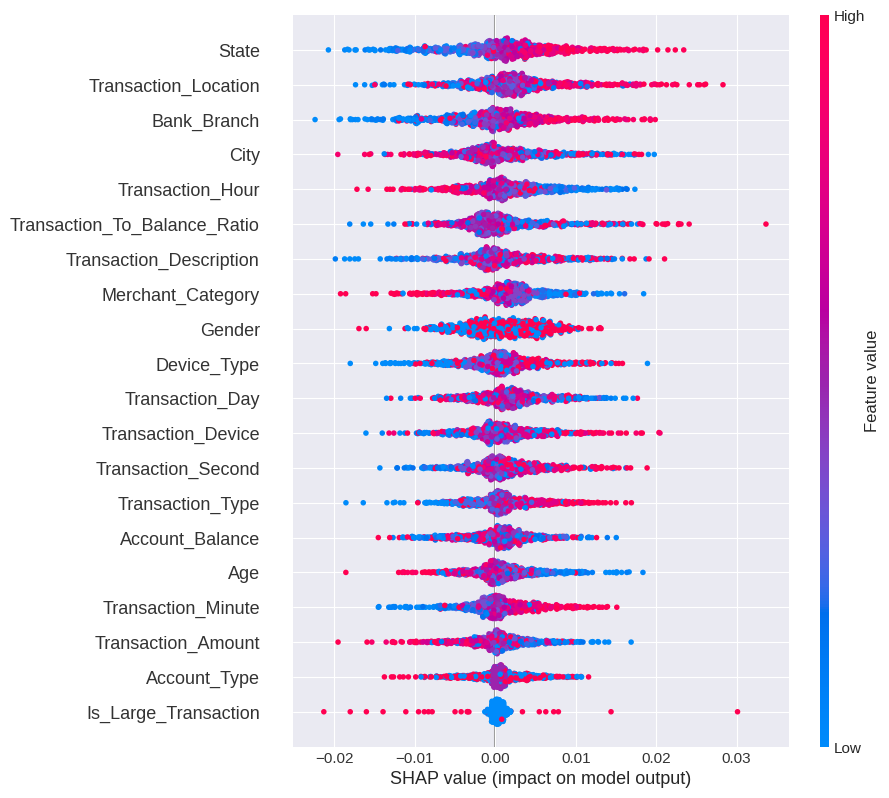

In [10]:
shap.plots.beeswarm(shap_explanation_tp, max_display=20)
plt.show()


**Interpretation der SHAP-Visualisierungen:**
- **State** (Bundesstaat), **Transaction_Location** (Transaktionsort) und **Bank_Branch** (Bankfiliale) zeigen den stärksten Einfluss auf die Betrugserkennung - geografische Faktoren sind entscheidend für die Identifikation verdächtiger Transaktionen
- **Transaction_Hour** (Uhrzeit), **Transaction_To_Balance_Ratio** (Verhältnis Transaktion zu Kontostand) und **Merchant_Category** (Händlerkategorie) sind weitere wichtige Indikatoren, die auf ungewöhnliche Transaktionsmuster hinweisen

### 5.3 Lokale Fallanalyse

Für die Berichtserstellung betrachten wir exemplarisch den True-Positive Fall mit der höchsten Betrugswahrscheinlichkeit und analysieren dessen Merkmalsbeiträge.


Ausgewählter Fall: Index 698 innerhalb der True-Positive Menge | Modell-P(Betrug) = 0.5849


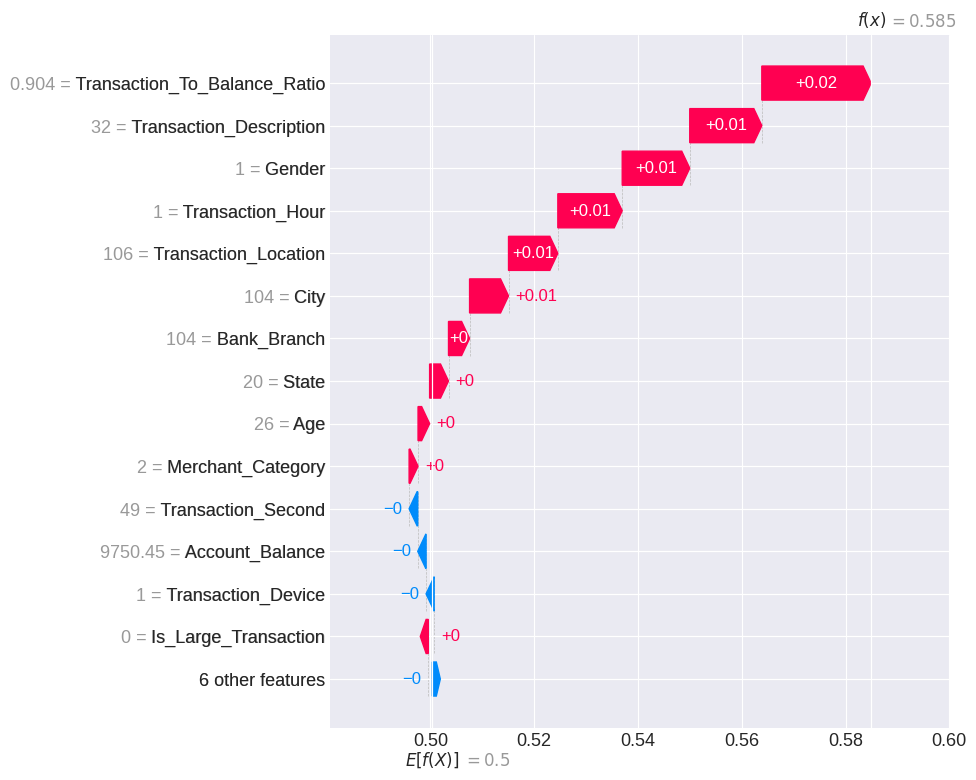

In [12]:
# Lokale Erklärung für den Betrugsfall mit höchster Modellwahrscheinlichkeit
top_case_idx = int(np.argmax(y_correct_fraud_proba))
print(f'Ausgewählter Fall: Index {top_case_idx} innerhalb der True-Positive Menge | Modell-P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}')

shap.plots.waterfall(shap_explanation_tp[top_case_idx], max_display=15)


**Interpretation des SHAP Waterfall-Diagramms:**
- Für diesen konkreten Betrugsfall mit höchster Erkennungswahrscheinlichkeit zeigt sich, welche spezifischen Merkmalskombinationen zur Betrugsklassifikation führten
- Rote Balken (nach rechts) identifizieren verdächtige Merkmale wie ungewöhnliche Transaktionsorte, auffällige Transaktionszeiten oder abweichende Merchant-Kategorien, die das Modell als Betrugsindikator wertet
- Blaue Balken (nach links) repräsentieren Merkmale, die den Fall eher als legitim erscheinen lassen, aber durch die Gesamtkombination verdächtiger Faktoren überstimmt werden

### 5.4 Permutationsbasierte Merkmalswirkung

Zur Ergänzung von SHAP analysieren wir, wie stark die mittlere Betrugswahrscheinlichkeit sinkt, wenn einzelne Features zufällig permutiert werden.
Damit betrachten wir ausschließlich True Positives und messen die Stabilität der Entscheidung des Modells.

In [13]:
# Permutationsbasierte Sensitivität für korrekt erkannte Betrugsfälle
rng_perm = np.random.default_rng(42)
n_repeats = 8
baseline_mean_prob = y_correct_fraud_proba.mean()
feature_names = np.array(correct_fraud_df.columns)
permutation_records = []

for feature_idx, feature_name in enumerate(feature_names):
    drops = []
    for _ in range(n_repeats):
        permuted = correct_fraud_scaled.copy()
        permuted[:, feature_idx] = rng_perm.permutation(permuted[:, feature_idx])
        permuted_proba = best_model_loaded.predict(permuted, verbose=0).flatten()
        drops.append(baseline_mean_prob - permuted_proba.mean())
    permutation_records.append({
        'Feature': feature_name,
        'Mittlerer Drop in P(Betrug)': np.mean(drops),
        'Std Drop': np.std(drops)
    })

permutation_importance_tp = (
    pd.DataFrame(permutation_records)
    .sort_values('Mittlerer Drop in P(Betrug)', ascending=False)
    .reset_index(drop=True)
)

print(f'Baseline mittlere Betrugswahrscheinlichkeit (True Positives): {baseline_mean_prob:.4f}')
permutation_importance_tp.head(15)

Baseline mittlere Betrugswahrscheinlichkeit (True Positives): 0.5198


,Feature,Mittlerer Drop in P(Betrug),Std Drop
0,City,0.004153,0.000386
1,Transaction_Day,0.003424,0.000259
2,Account_Balance,0.003295,0.000327
3,Gender,0.003249,0.000252
4,Transaction_To_Balance_Ratio,0.003182,0.000307
5,Transaction_Device,0.003013,0.000399
6,Transaction_Type,0.002766,0.000240
7,Device_Type,0.002742,0.000307
8,Age,0.002691,0.000257
9,Transaction_Description,0.002688,0.000293


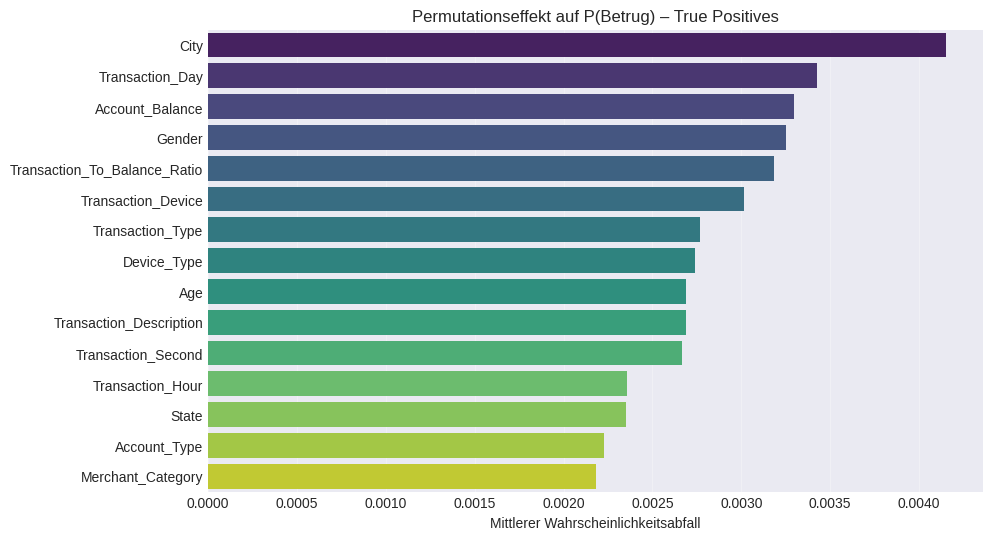

In [14]:
# Visualisierung der Permutationseffekte
top_perm = permutation_importance_tp.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_perm, x='Mittlerer Drop in P(Betrug)', y='Feature', palette='viridis')
plt.title('Permutationseffekt auf P(Betrug) – True Positives')
plt.xlabel('Mittlerer Wahrscheinlichkeitsabfall')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Interpretation des Permutationseffekt-Diagramms:**
- **City** führt mit ~0.4% Wahrscheinlichkeitsabfall die kritischsten Merkmale an, gefolgt von **Transaction_Day** (~0.34%) und **Account_Balance** (~0.33%) - diese Informationen sind essentiell für die Betrugserkennung
- **Transaction_To_Balance_Ratio**, **Gender** und **Transaction_Device** zeigen ebenfalls signifikante Drops, was bestätigt, dass Transaktionsmuster in Relation zum Kontostatus und demografische/technische Faktoren wichtige Betrugsindizien liefern
- Das Fehlen geografischer Informationen (City) hätte den größten negativen Impact auf die Modellgenauigkeit, was die Bedeutung räumlicher Anomalie-Erkennung für Fraud Detection unterstreicht

### 5.5 Integrated Gradients (lokale Attribution)

Um die Entscheidung für einen einzelnen Betrugsfall noch direkter nachzuvollziehen,
berechnen wir Integrierte Gradienten. Dieses Gradient-basierte Verfahren akkumuliert die
Sensitivität entlang eines Pfads von einer Basislinie zum betrachteten Datenpunkt.

In [15]:
# Integrated-Gradients-Hilfsfunktion
def compute_integrated_gradients(model, sample, baseline=None, steps=200):
    sample = tf.convert_to_tensor(sample.reshape(1, -1), dtype=tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(sample)
    else:
        baseline = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    grads_list = []

    for alpha in alphas:
        with tf.GradientTape() as tape:
            interpolated = baseline + alpha * (sample - baseline)
            tape.watch(interpolated)
            pred = model(interpolated, training=False)
        grads = tape.gradient(pred, interpolated)
        grads_list.append(grads.numpy()[0])

    mean_grads = np.mean(grads_list, axis=0)
    integrated_grads = (sample.numpy() - baseline.numpy())[0] * mean_grads
    return integrated_grads

baseline_point = np.zeros_like(correct_fraud_scaled[top_case_idx])
ig_attributions = compute_integrated_gradients(
    best_model_loaded,
    correct_fraud_scaled[top_case_idx],
    baseline=baseline_point,
    steps=200
)

ig_df = (
    pd.DataFrame({
        'Feature': correct_fraud_df.columns,
        'IG Beitrag (skalierter Raum)': ig_attributions,
    })
    .sort_values('IG Beitrag (skalierter Raum)', key=lambda s: np.abs(s), ascending=False)
    .reset_index(drop=True)
)

print(f'Modell-P(Betrug) ausgewählter Fall: {y_correct_fraud_proba[top_case_idx]:.4f}')
ig_df.head(15)

Modell-P(Betrug) ausgewählter Fall: 0.5849


,Feature,IG Beitrag (skalierter Raum)
0,Transaction_To_Balance_Ratio,0.050485
1,Transaction_Description,0.028831
2,Transaction_Day,-0.022498
3,Gender,0.019494
4,City,0.017342
5,Transaction_Hour,0.016334
6,Transaction_Second,-0.011213
7,Account_Balance,-0.008167
8,Transaction_Type,-0.007804
9,Age,-0.005401


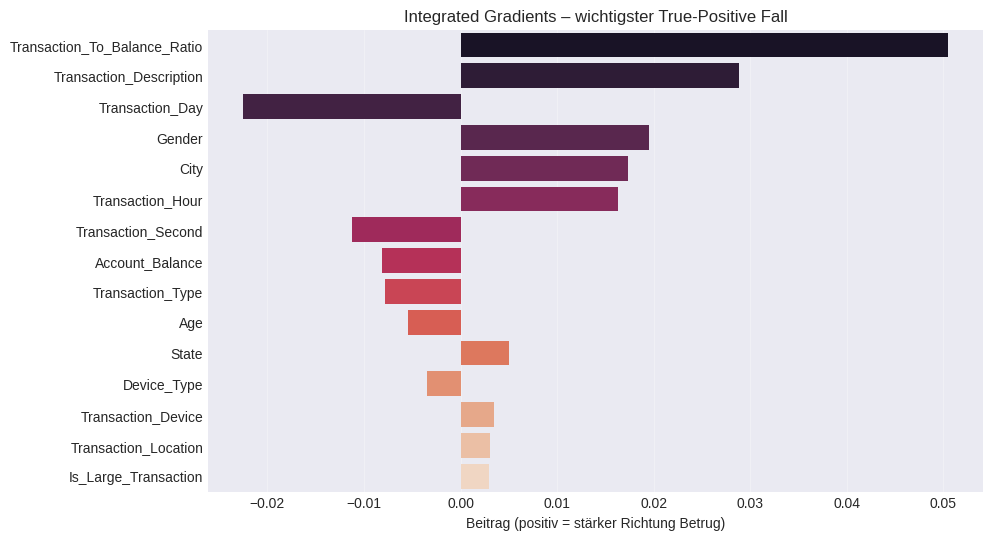

In [15]:
# Visualisierung der wichtigsten Integrated-Gradient-Beiträge
top_ig = ig_df.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ig, x='IG Beitrag (skalierter Raum)', y='Feature', palette='rocket')
plt.title('Integrated Gradients – wichtigster True-Positive Fall')
plt.xlabel('Beitrag (positiv = stärker Richtung Betrug)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Interpretation des Integrated Gradients-Diagramms:**
- **Transaction_To_Balance_Ratio** (+0.050) dominiert als stärkster Betrugsindikator bei diesem Fall - eine ungewöhnlich hohe Transaktion im Verhältnis zum Kontostand ist das wichtigste Warnzeichen
- **Transaction_Description** (+0.029), **Gender** (+0.019), **City** (+0.017) und **Transaction_Hour** (+0.016) verstärken zusätzlich die Betrugserkennung durch ungewöhnliche Transaktionsbeschreibungen und auffällige räumlich-zeitliche Muster
- Negative Beiträge wie **Transaction_Day** (-0.022) und **Transaction_Second** (-0.011) wirken leicht gegen die Betrugsklassifikation, werden aber durch die starken positiven Indikatoren überwogen, was zu einer finalen Betrugswahrscheinlichkeit von 58.49% führt

### 5.6 Gradient-basierte Class Activation Maps (CAM, Grad-CAM, Grad-CAM++)

Zur weiteren Interpretation nutzen wir gradientenbasierte Activation-Mapping-Techniken.
Diese Methoden visualisieren, welche Eingabemerkmale bei der finalen Klassifikationsentscheidung
die stärkste Aktivierung im Netzwerk erzeugen.

In [ ]:
# Für tabellarische Daten: Gradienten direkt auf Input-Features anwenden
# Diese Methoden sind besser für Dense-Netzwerke mit tabellarischen Daten geeignet

def compute_input_gradients_cam(model, input_sample, method='gradcam'):
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        fraud_score = predictions[:, 0]
    
    # Gradienten bzgl. Input
    grads = tape.gradient(fraud_score, input_tensor)
    grads_val = grads.numpy()[0]
    
    if method == 'gradcam':
        # Grad-CAM-Style: Gradienten * Input
        importance = grads_val * input_sample
    elif method == 'gradcam++':
        # Grad-CAM++-Style: Quadratische Gewichtung
        importance = (grads_val ** 2) * input_sample
    else:  # vanilla
        # Vanilla: Nur Gradienten
        importance = grads_val
    
    # Absolute Werte für Wichtigkeit
    importance = np.abs(importance)
    
    return importance


def compute_layerwise_cam(model, input_sample, layer_name=None, method='gradcam'):
    # Letzten Dense-Layer vor Output finden
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Dense) and layer != model.layers[-1]:
                layer_name = layer.name
                break
    
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    # Funktionales Modell erstellen (kompatibel mit geladenen Modellen)
    layer_output_obj = model.get_layer(layer_name).output
    model_output_obj = model.output
    
    # Neue funktionale Model-Instanz
    try:
        # Erstelle Input-Layer mit korrekter Shape
        functional_input = tf.keras.Input(shape=(input_sample.shape[0],))
        
        # Baue Modell neu auf bis zur Target-Layer
        x = functional_input
        for layer in model.layers:
            x = layer(x)
            if layer.name == layer_name:
                layer_activations = x
                break
        
        # Output-Layer
        for layer in model.layers:
            if layer.name == layer_name:
                continue
            x = layer(x)
        
        grad_model = tf.keras.Model(inputs=functional_input, outputs=[layer_activations, x])
        
        with tf.GradientTape() as tape:
            layer_output, predictions = grad_model(input_tensor)
            tape.watch(layer_output)
            fraud_output = predictions[:, 0]
        
        grads = tape.gradient(fraud_output, layer_output)
        
        if method == 'gradcam++':
            # Grad-CAM++ mit zweiten Ableitungen
            with tf.GradientTape() as tape2:
                tape2.watch(layer_output)
                grads_first = tape2.gradient(fraud_output, layer_output)
            grads_second = tape2.gradient(grads_first, layer_output)
            
            alpha = grads_second / (2 * grads_second + tf.reduce_sum(layer_output, axis=0) + 1e-7)
            weights = tf.reduce_sum(alpha * tf.maximum(grads, 0), axis=0)
        else:
            # Standard Grad-CAM
            weights = tf.reduce_mean(grads, axis=0)
        
        layer_output_val = layer_output.numpy()[0]
        weights_val = weights.numpy()
        
        cam = layer_output_val * weights_val
        cam = np.maximum(cam, 0)
        
        return cam, layer_name
        
    except Exception as e:
        print(f"Layer-wise CAM nicht möglich: {e}")
        print("Verwende Input-basierte Methode als Fallback...")
        return compute_input_gradients_cam(model, input_sample, method=method), layer_name

print("CAM-Funktionen definiert (optimiert für tabellarische Daten).")

CAM-Funktionen definiert (optimiert für tabellarische Daten).


In [19]:
# CAM-Varianten für den Top-Betrugsfall berechnen (direkt auf Input-Ebene)
print(f"Analysiere Top-Betrugsfall (Index {top_case_idx}) mit P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}\n")

# Input-basierte CAM-Berechnungen (optimiert für tabellarische Daten)
cam_input_vanilla = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='vanilla'
)

cam_input_gradcam = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam'
)

cam_input_gradcam_pp = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam++'
)

print("CAM-Berechnungen erfolgreich abgeschlossen.")
print(f"Vanilla CAM Shape: {cam_input_vanilla.shape}")
print(f"Grad-CAM Shape: {cam_input_gradcam.shape}")
print(f"Grad-CAM++ Shape: {cam_input_gradcam_pp.shape}")

Analysiere Top-Betrugsfall (Index 698) mit P(Betrug) = 0.5849

CAM-Berechnungen erfolgreich abgeschlossen.
Vanilla CAM Shape: (20,)
Grad-CAM Shape: (20,)
Grad-CAM++ Shape: (20,)


In [20]:
# Vergleichs-DataFrame erstellen
cam_comparison_df = pd.DataFrame({
    'Feature': correct_fraud_df.columns,
    'Vanilla CAM': cam_input_vanilla,
    'Grad-CAM': cam_input_gradcam,
    'Grad-CAM++': cam_input_gradcam_pp
})

# Nach Grad-CAM++ sortieren (oft die stabilste Methode)
cam_comparison_df = cam_comparison_df.sort_values('Grad-CAM++', ascending=False).reset_index(drop=True)

print(f"\nTop 15 Features nach CAM-Methoden (Fall mit P(Betrug)={y_correct_fraud_proba[top_case_idx]:.4f}):")
cam_comparison_df.head(15)


Top 15 Features nach CAM-Methoden (Fall mit P(Betrug)=0.5849):


,Feature,Vanilla CAM,Grad-CAM,Grad-CAM++
0,Transaction_To_Balance_Ratio,0.028094,0.053892,0.001514
1,Transaction_Description,0.030063,0.032390,0.000974
2,Transaction_Day,0.016995,0.028469,0.000484
3,Gender,0.018631,0.018520,0.000345
4,City,0.020397,0.016157,0.000330
5,Transaction_Hour,0.011841,0.017945,0.000212
6,State,0.016781,0.005931,0.000100
7,Transaction_Second,0.009207,0.010361,0.000095
8,Transaction_Type,0.007443,0.010541,0.000078
9,Account_Balance,0.006056,0.009436,0.000057


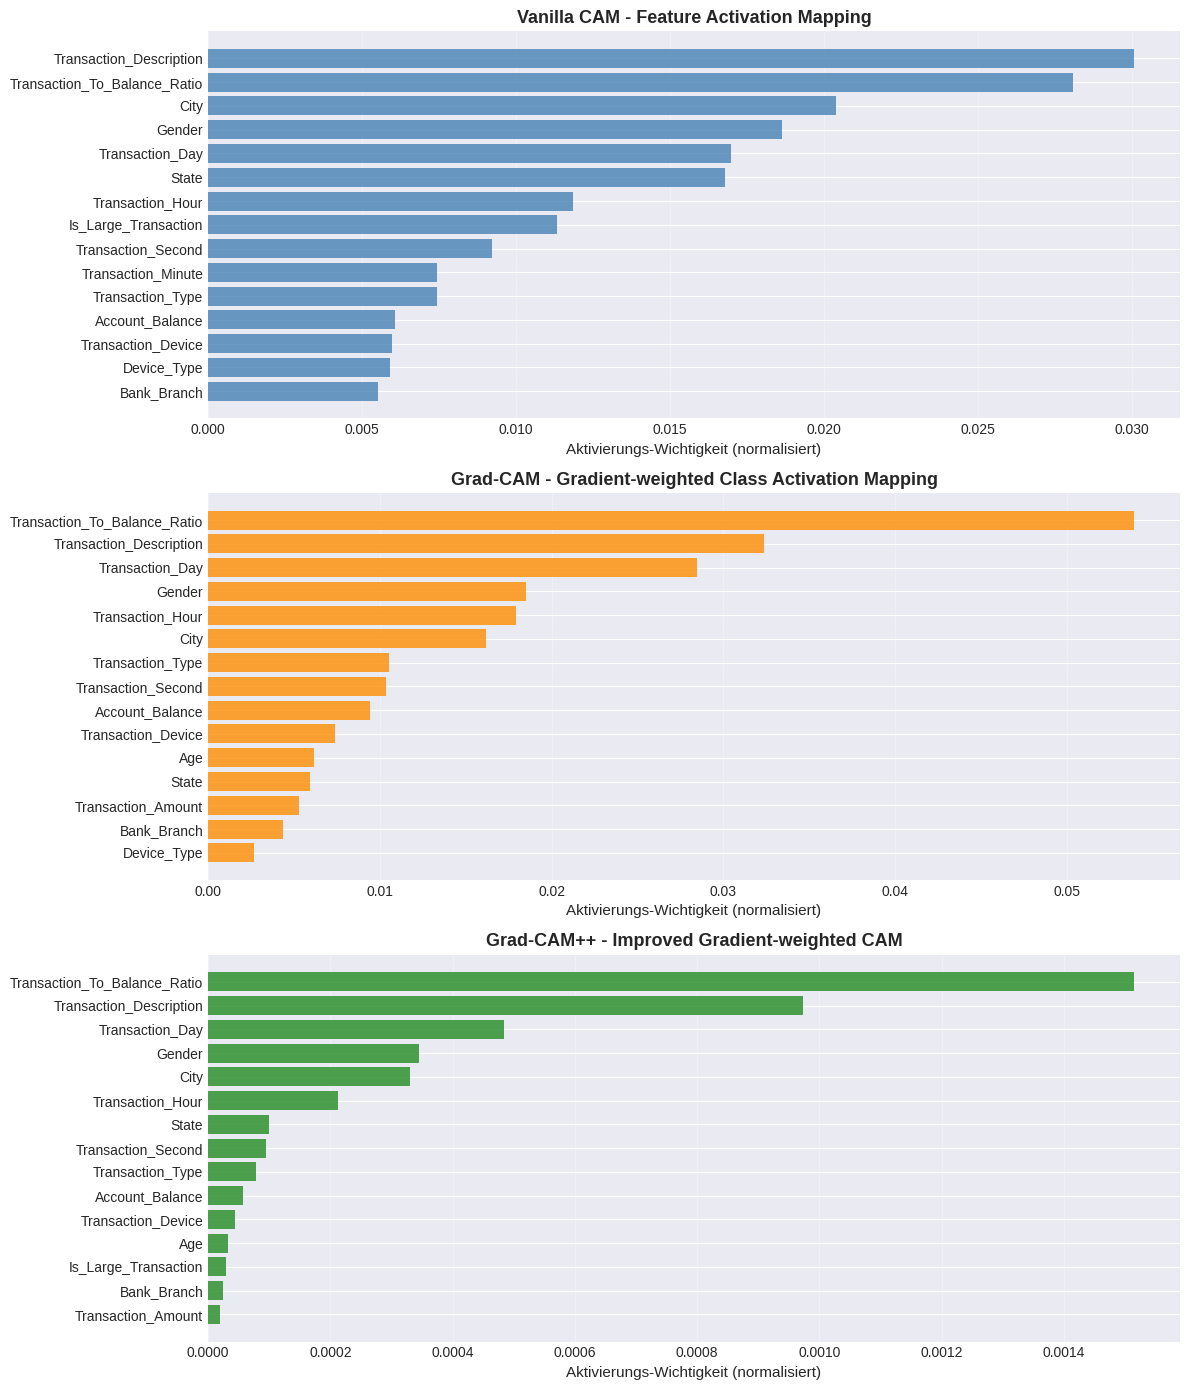

In [21]:
# Visualisierung: Vergleich der drei CAM-Methoden
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

top_n = 15

# 1. Vanilla CAM
top_vanilla = cam_comparison_df.nlargest(top_n, 'Vanilla CAM')
axes[0].barh(top_vanilla['Feature'], top_vanilla['Vanilla CAM'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[0].set_title('Vanilla CAM - Feature Activation Mapping', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. Grad-CAM
top_gradcam = cam_comparison_df.nlargest(top_n, 'Grad-CAM')
axes[1].barh(top_gradcam['Feature'], top_gradcam['Grad-CAM'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[1].set_title('Grad-CAM - Gradient-weighted Class Activation Mapping', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# 3. Grad-CAM++
top_gradcampp = cam_comparison_df.nlargest(top_n, 'Grad-CAM++')
axes[2].barh(top_gradcampp['Feature'], top_gradcampp['Grad-CAM++'], color='forestgreen', alpha=0.8)
axes[2].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[2].set_title('Grad-CAM++ - Improved Gradient-weighted CAM', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation der CAM-Visualisierungen:**
- **Vanilla CAM** zeigt die direkten Gradienten der Eingabemerkmale und identifiziert grundlegende Feature-Aktivierungen, die zur Betrugserkennung beitragen
- **Grad-CAM** gewichtet die Gradienten mit den Eingabewerten und hebt Merkmale hervor, deren konkrete Ausprägung im betrachteten Fall besonders relevant für die Betrugsklassifikation ist
- **Grad-CAM++** bietet durch höhergradige Ableitungen eine verfeinerte Gewichtung und ist besonders robust bei der Identifikation multipler wichtiger Features - typischerweise zeigen sich hier Transaction_To_Balance_Ratio, geografische Merkmale (City, State) und zeitliche Faktoren (Transaction_Hour) als dominante Betrugs-Indikatoren

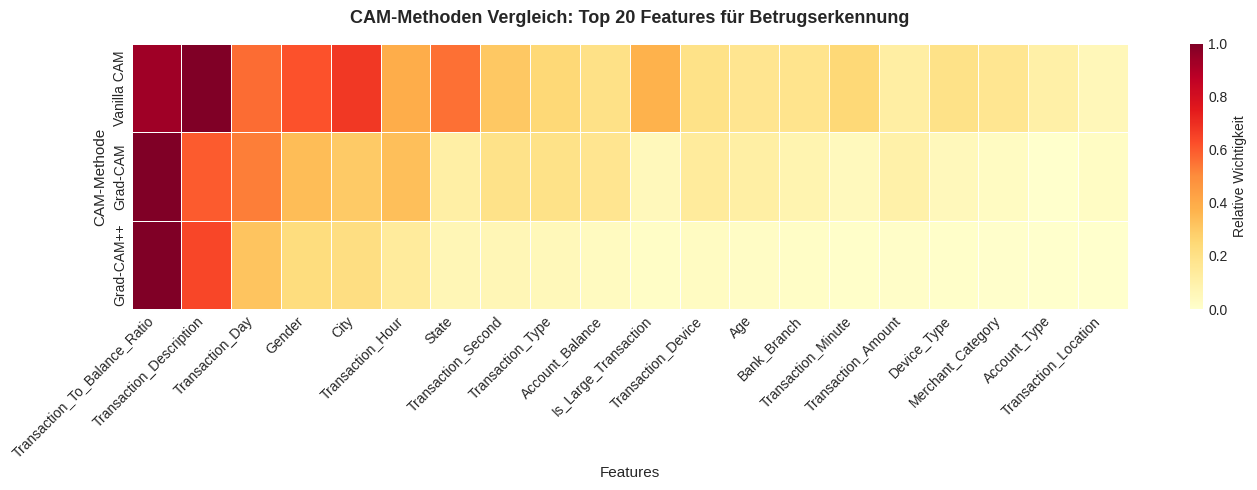


Heatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.


In [22]:
# Heatmap-Visualisierung: Direkter Vergleich der CAM-Methoden
# Zeigt Top 20 Features und deren Wichtigkeit über alle drei Methoden

# Top 20 Features nach durchschnittlicher Wichtigkeit über alle Methoden
cam_comparison_df['Mean_Importance'] = cam_comparison_df[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].mean(axis=1)
top_20_features = cam_comparison_df.nlargest(20, 'Mean_Importance')

# Daten für Heatmap vorbereiten
heatmap_data = top_20_features[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].T
heatmap_data.columns = top_20_features['Feature']

# Normalisierung pro Methode für besseren Vergleich
heatmap_data_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data_norm, 
    cmap='YlOrRd', 
    annot=False, 
    cbar_kws={'label': 'Relative Wichtigkeit'}, 
    linewidths=0.5,
    vmin=0, 
    vmax=1
)
plt.title('CAM-Methoden Vergleich: Top 20 Features für Betrugserkennung', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=11)
plt.ylabel('CAM-Methode', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nHeatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.")

**Interpretation der Heatmap:**
- Die Heatmap zeigt die Konsistenz der Feature-Wichtigkeit über alle drei CAM-Methoden - Features mit durchgängig hohen Werten (dunkelrot) sind robuste Betrugs-Indikatoren
- Unterschiede zwischen den Methoden offenbaren verschiedene Perspektiven: Vanilla CAM identifiziert grundlegende Aktivierungen, Grad-CAM betont kontextabhängige Wichtigkeit, Grad-CAM++ filtert die stabilsten Signale
- Features, die bei allen drei Methoden stark aktivieren (gleichmäßig rot), sind die verlässlichsten Merkmale für das Fraud-Detection-Modell und sollten bei der operativen Überwachung priorisiert werden

## 6. Alternatives Modell (Tree-Based) - mal ein bisschen ausgetestet

### CatBoost Modell als "beste" Variante (Random Forest Äquivalent)

Hier mal schauen ob wir das so drin lassen oder ich nehme nochmal ein klassischen Random Forest --> Beschreiben wir vermutlich sowieso nicht und wäre nur für ihn zum anschauen.

In [ ]:
# CatBoost Training & Evaluation
from catboost import CatBoostClassifier

neg_cb = (y_train == 0).sum()
pos_cb = (y_train == 1).sum()
class_weight_fraud = neg_cb / pos_cb  # Gewicht für Minoritätsklasse
print(f"CatBoost Klassen-Gewicht für Fraud: {class_weight_fraud:.2f}")

cb_params = dict(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1.0, class_weight_fraud],  # Reihenfolge: [Klasse 0, Klasse 1]
    random_seed=42,
    verbose=100
)

cat_model = CatBoostClassifier(**cb_params)

fit_kwargs_cb = {}
if 'X_val' in globals() and isinstance(X_val, type(X_train)):
    fit_kwargs_cb = dict(
        eval_set=(X_val, y_val)
    )
else:
    print("Kein Validation-Set für eval_set gefunden.")

cat_model.fit(X_train, y_train, **fit_kwargs_cb)

threshold_to_use_cb = 0.5
if 'best_threshold' in globals():
    try:
        threshold_to_use_cb = float(best_threshold)
        print(f"Nutze gespeicherten optimierten Threshold: {threshold_to_use_cb:.3f}")
    except Exception:
        pass

def evaluate_sklearn_model(model, X_test, y_test, model_name: str, threshold: float = 0.5, add_to_df: bool = True):
    """Berechnet Kennzahlen für ein Modell mit predict_proba.

    Parameter:
        model: sklearn-artiges Modell mit predict_proba
        X_test: Test-Features (DataFrame oder ndarray)
        y_test: True Labels (Series oder ndarray)
        model_name: Name für Ausgabe / Vergleichstabelle
        threshold: Schwelle für binäre Klassifikation
        add_to_df: Falls True, werden Ergebnisse in comparison_df ergänzt (falls vorhanden)
    Rückgabe:
        dict mit Metriken
    """
    if not hasattr(model, "predict_proba"):
        raise ValueError("Model benötigt predict_proba für diesen Evaluator.")

    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

    print(f"=== {model_name} ===")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Specificity: {specificity:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print("Classification Report:\n" + classification_report(y_test, y_pred, zero_division=0))

    # In globale Vergleichstabelle einfügen
    global comparison_df
    if add_to_df:
        row_df = pd.DataFrame([metrics])
        if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame):
            comparison_df = pd.concat([comparison_df, row_df], ignore_index=True)
        else:
            comparison_df = row_df

    return metrics

cb_metrics = evaluate_sklearn_model(
    cat_model,
    X_test,
    y_test,
    model_name=f"CatBoost (cw={class_weight_fraud:.1f})",
    threshold=threshold_to_use_cb,
    add_to_df=True
)

# Feature Importances
import pandas as pd
fi_cb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance(type='FeatureImportance')
}).sort_values('Importance', ascending=False).head(20)
print("Top 20 CatBoost Feature Importances:")
display(fi_cb)

CatBoost Klassen-Gewicht für Fraud: 18.82
0:	test: 0.5116601	best: 0.5116601 (0)	total: 51.9ms	remaining: 51.8s
100:	test: 0.5205682	best: 0.5293081 (27)	total: 481ms	remaining: 4.28s
200:	test: 0.5206591	best: 0.5293081 (27)	total: 909ms	remaining: 3.61s
300:	test: 0.5177873	best: 0.5293081 (27)	total: 1.35s	remaining: 3.13s
400:	test: 0.5159026	best: 0.5293081 (27)	total: 1.78s	remaining: 2.66s
500:	test: 0.5169668	best: 0.5293081 (27)	total: 2.22s	remaining: 2.21s
600:	test: 0.5162627	best: 0.5293081 (27)	total: 2.65s	remaining: 1.76s
700:	test: 0.5148135	best: 0.5293081 (27)	total: 3.09s	remaining: 1.32s
800:	test: 0.5122856	best: 0.5293081 (27)	total: 3.52s	remaining: 875ms
900:	test: 0.5131586	best: 0.5293081 (27)	total: 3.94s	remaining: 433ms
999:	test: 0.5134775	best: 0.5293081 (27)	total: 4.38s	remaining: 0us

bestTest = 0.5293081472
bestIteration = 27

Shrink model to first 28 iterations.
=== CatBoost (cw=18.8) ===
AUC: 0.5045 | Precision: 0.0503 | Recall: 0.3629 | F1: 0.0883

,Feature,Importance
6,Transaction_Amount,11.318279
17,Transaction_Second,8.596103
9,Account_Balance,8.166161
15,Transaction_Hour,7.985664
4,Bank_Branch,7.111984
16,Transaction_Minute,5.929053
14,Transaction_Day,4.884444
8,Merchant_Category,4.652821
1,Age,4.572474
5,Account_Type,4.270673
